In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
df = pd.read_csv("global_ads_performance.csv")
df.head()

,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
0,1/21/2024,Google Ads,Search,Fintech,UAE,59886,2113,0.0353,1.26,2662.38,159,16.74,4803.43,1.80
1,1/22/2024,TikTok Ads,Search,EdTech,UK,135608,5220,0.0385,1.18,6159.60,411,14.99,64126.68,10.41
2,6/15/2024,TikTok Ads,Video,Healthcare,USA,92313,5991,0.0649,0.85,5092.35,267,19.07,10489.07,2.06
3,1/2/2024,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.0707,1.32,7834.20,296,26.47,50505.07,6.45
4,2/22/2024,TikTok Ads,Search,Healthcare,UK,91807,4489,0.0489,1.93,8663.77,107,80.97,3369.53,0.39


In [3]:
df.shape

(1800, 14)

In [7]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
date             0
platform         0
campaign_type    0
industry         0
country          0
impressions      0
clicks           0
CTR              0
CPC              0
ad_spend         0
conversions      0
CPA              0
revenue          0
ROAS             0
dtype: int64

Duplicate rows:
0


In [9]:
df["date"] = pd.to_datetime(df["date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1800 non-null   datetime64[us]
 1   platform       1800 non-null   str           
 2   campaign_type  1800 non-null   str           
 3   industry       1800 non-null   str           
 4   country        1800 non-null   str           
 5   impressions    1800 non-null   int64         
 6   clicks         1800 non-null   int64         
 7   CTR            1800 non-null   float64       
 8   CPC            1800 non-null   float64       
 9   ad_spend       1800 non-null   float64       
 10  conversions    1800 non-null   int64         
 11  CPA            1800 non-null   float64       
 12  revenue        1800 non-null   float64       
 13  ROAS           1800 non-null   float64       
dtypes: datetime64[us](1), float64(6), int64(3), str(4)
memory usage: 197.0 KB


In [10]:
df.describe().round(2)

,date,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
count,1800,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00
mean,2024-06-28 12:56:00,102919.02,3962.68,0.04,1.57,6171.53,181.56,46.61,30101.85,6.45
min,2024-01-01 00:00:00,5059.00,91.00,0.01,0.28,58.00,2.00,4.80,142.69,0.13
25%,2024-03-27 18:00:00,54948.00,1678.00,0.03,0.95,1966.59,59.00,20.20,7275.76,2.17
50%,2024-06-26 00:00:00,103653.00,3318.00,0.04,1.46,4393.86,130.00,33.38,18362.96,4.30
75%,2024-09-26 00:00:00,150470.25,5628.00,0.05,2.05,8455.83,252.25,56.81,38963.38,8.21
max,2024-12-30 00:00:00,199650.00,16660.00,0.10,3.95,38453.32,1151.00,335.86,295028.26,49.00
std,NaN,55740.90,2941.86,0.02,0.80,5777.00,171.42,41.19,34560.03,6.59


In [11]:
platform_summary = df.groupby("platform").agg(

    campaigns=("platform", "size"),

    impressions=("impressions", "sum"),

    clicks=("clicks", "sum"),

    ad_spend=("ad_spend", "sum"),

    conversions=("conversions", "sum"),

    revenue=("revenue", "sum")

).reset_index()

platform_summary["CTR"] = (

    platform_summary["clicks"] / platform_summary["impressions"]

)

platform_summary["CPC"] = (

    platform_summary["ad_spend"] / platform_summary["clicks"]

)

platform_summary["CPA"] = (

    platform_summary["ad_spend"] / platform_summary["conversions"]

)

platform_summary["ROAS"] = (

    platform_summary["revenue"] / platform_summary["ad_spend"]

)

platform_summary.round(2).sort_values("ROAS", ascending=False)

,platform,campaigns,impressions,clicks,ad_spend,conversions,revenue,CTR,CPC,CPA,ROAS
2,TikTok Ads,450,47049590,2599931,2653418.51,122452,20223540.07,0.06,1.02,21.67,7.62
1,Meta Ads,630,64403494,1596736,2106061.67,73262,11926045.79,0.02,1.32,28.75,5.66
0,Google Ads,720,73801150,2936149,6349268.91,131098,22033744.95,0.04,2.16,48.43,3.47


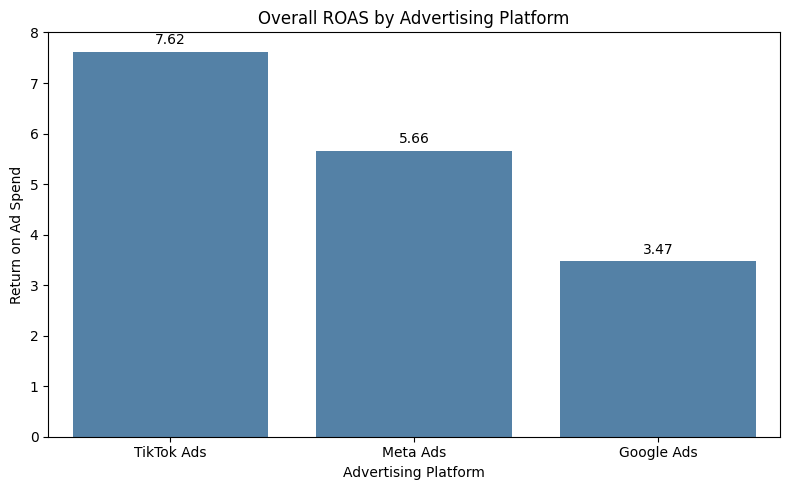

In [12]:
roas_chart = platform_summary.sort_values("ROAS", ascending=False)

plt.figure(figsize=(8, 5))

ax = sns.barplot(

    data=roas_chart,

    x="platform",

    y="ROAS",

    color="steelblue"

)

for container in ax.containers:

    ax.bar_label(container, fmt="%.2f", padding=3)

plt.title("Overall ROAS by Advertising Platform")

plt.xlabel("Advertising Platform")

plt.ylabel("Return on Ad Spend")

plt.tight_layout()

plt.show()

In [13]:
campaign_summary = df.groupby("campaign_type").agg(

    campaigns=("campaign_type", "size"),

    impressions=("impressions", "sum"),

    clicks=("clicks", "sum"),

    ad_spend=("ad_spend", "sum"),

    conversions=("conversions", "sum"),

    revenue=("revenue", "sum")

).reset_index()

campaign_summary["CTR"] = (

    campaign_summary["clicks"] / campaign_summary["impressions"]

)

campaign_summary["CPC"] = (

    campaign_summary["ad_spend"] / campaign_summary["clicks"]

)

campaign_summary["CPA"] = (

    campaign_summary["ad_spend"] / campaign_summary["conversions"]

)

campaign_summary["ROAS"] = (

    campaign_summary["revenue"] / campaign_summary["ad_spend"]

)

campaign_summary.round(2).sort_values("ROAS", ascending=False)

,campaign_type,campaigns,impressions,clicks,ad_spend,conversions,revenue,CTR,CPC,CPA,ROAS
1,Search,477,47544475,1898227,2868006.85,90641,15218470.85,0.04,1.51,31.64,5.31
0,Display,420,43487104,1638396,2644735.12,76869,12798903.17,0.04,1.61,34.41,4.84
3,Video,456,47748617,1810883,2796458.48,79228,13341261.19,0.04,1.54,35.30,4.77
2,Shopping,447,46474038,1785310,2799548.64,80074,12824695.60,0.04,1.57,34.96,4.58


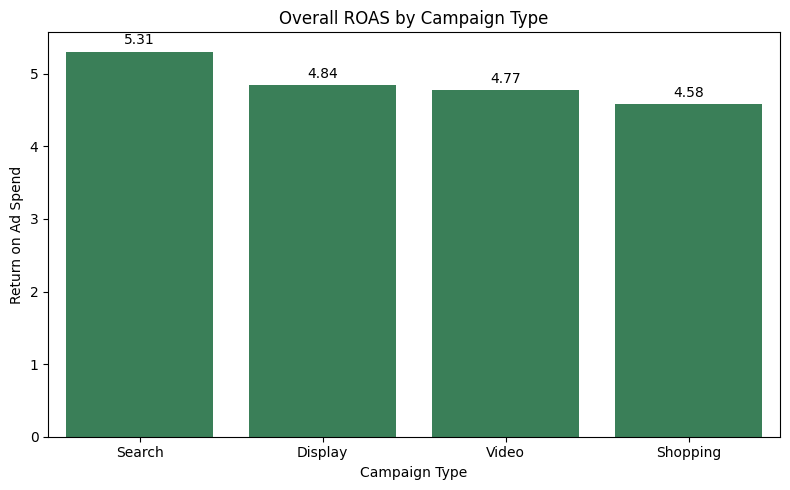

In [14]:
campaign_chart = campaign_summary.sort_values("ROAS", ascending=False)

plt.figure(figsize=(8, 5))

ax = sns.barplot(

    data=campaign_chart,

    x="campaign_type",

    y="ROAS",

    color="seagreen"

)

for container in ax.containers:

    ax.bar_label(container, fmt="%.2f", padding=3)

plt.title("Overall ROAS by Campaign Type")

plt.xlabel("Campaign Type")

plt.ylabel("Return on Ad Spend")

plt.tight_layout()

plt.show()

In [15]:
industry_summary = df.groupby("industry").agg(

    campaigns=("industry", "size"),

    impressions=("impressions", "sum"),

    clicks=("clicks", "sum"),

    ad_spend=("ad_spend", "sum"),

    conversions=("conversions", "sum"),

    revenue=("revenue", "sum")

).reset_index()

industry_summary["CTR"] = (

    industry_summary["clicks"] / industry_summary["impressions"]

)

industry_summary["CPA"] = (

    industry_summary["ad_spend"] / industry_summary["conversions"]

)

industry_summary["ROAS"] = (

    industry_summary["revenue"] / industry_summary["ad_spend"]

)

industry_summary.round(2).sort_values("ROAS", ascending=False)

,industry,campaigns,impressions,clicks,ad_spend,conversions,revenue,CTR,CPA,ROAS
4,SaaS,370,38033868,1551055,2357561.84,71261,11891991.42,0.04,33.08,5.04
1,EdTech,372,39833845,1502152,2296978.52,67257,11549934.43,0.04,34.15,5.03
0,E-commerce,349,33800712,1280139,1923987.08,57486,9637279.69,0.04,33.47,5.01
3,Healthcare,348,36619145,1387123,2258683.92,65687,10930814.04,0.04,34.39,4.84
2,Fintech,361,36966664,1412347,2271537.73,65121,10173311.23,0.04,34.88,4.48


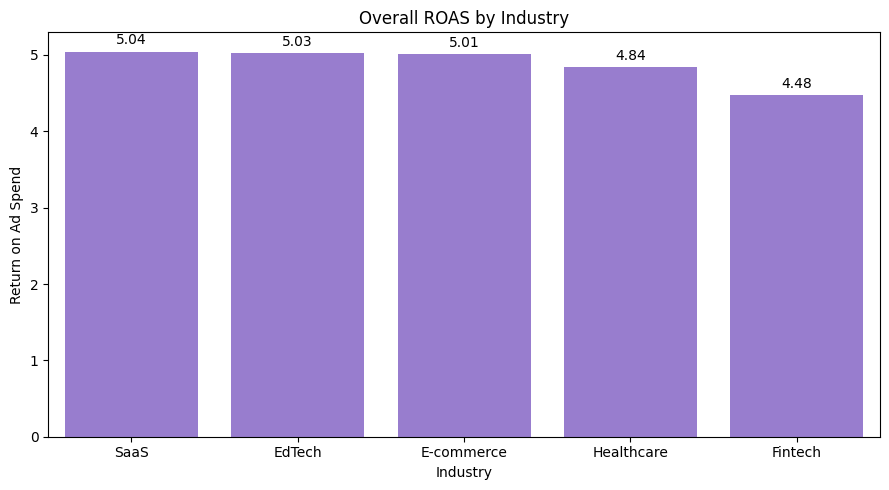

In [16]:
industry_chart = industry_summary.sort_values("ROAS", ascending=False)

plt.figure(figsize=(9, 5))

ax = sns.barplot(

    data=industry_chart,

    x="industry",

    y="ROAS",

    color="mediumpurple"

)

for container in ax.containers:

    ax.bar_label(container, fmt="%.2f", padding=3)

plt.title("Overall ROAS by Industry")

plt.xlabel("Industry")

plt.ylabel("Return on Ad Spend")

plt.tight_layout()

plt.show()

In [17]:
country_summary = df.groupby("country").agg(

    campaigns=("country", "size"),

    impressions=("impressions", "sum"),

    clicks=("clicks", "sum"),

    ad_spend=("ad_spend", "sum"),

    conversions=("conversions", "sum"),

    revenue=("revenue", "sum")

).reset_index()

country_summary["CTR"] = (

    country_summary["clicks"] / country_summary["impressions"]

)

country_summary["CPA"] = (

    country_summary["ad_spend"] / country_summary["conversions"]

)

country_summary["ROAS"] = (

    country_summary["revenue"] / country_summary["ad_spend"]

)

country_summary.round(2).sort_values("ROAS", ascending=False)

,country,campaigns,impressions,clicks,ad_spend,conversions,revenue,CTR,CPA,ROAS
3,India,261,26553737,1015783,1438741.76,46767,7909606.26,0.04,30.76,5.50
0,Australia,232,23801500,960925,1586264.94,45869,7921847.84,0.04,34.58,4.99
2,Germany,255,26118806,994571,1551062.17,44768,7694838.61,0.04,34.65,4.96
5,UK,266,26931459,1006651,1547153.48,46842,7659544.29,0.04,33.03,4.95
4,UAE,258,26781852,1056222,1614677.33,48345,7939594.41,0.04,33.40,4.92
1,Canada,262,27401283,1034804,1643262.54,46243,7867323.12,0.04,35.54,4.79
6,USA,266,27665597,1063860,1727586.87,47978,7190576.28,0.04,36.01,4.16


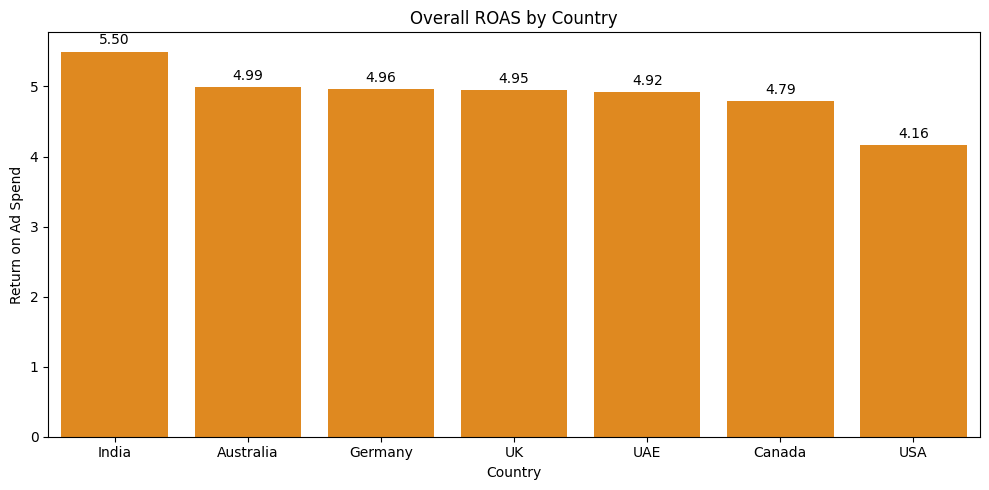

In [18]:
country_chart = country_summary.sort_values("ROAS", ascending=False)

plt.figure(figsize=(10, 5))

ax = sns.barplot(

    data=country_chart,

    x="country",

    y="ROAS",

    color="darkorange"

)

for container in ax.containers:

    ax.bar_label(container, fmt="%.2f", padding=3)

plt.title("Overall ROAS by Country")

plt.xlabel("Country")

plt.ylabel("Return on Ad Spend")

plt.tight_layout()

plt.show()

Ad spend vs. revenue correlation: 0.48
Ad spend vs. conversions correlation: 0.56
Ad spend vs. ROAS correlation: -0.26


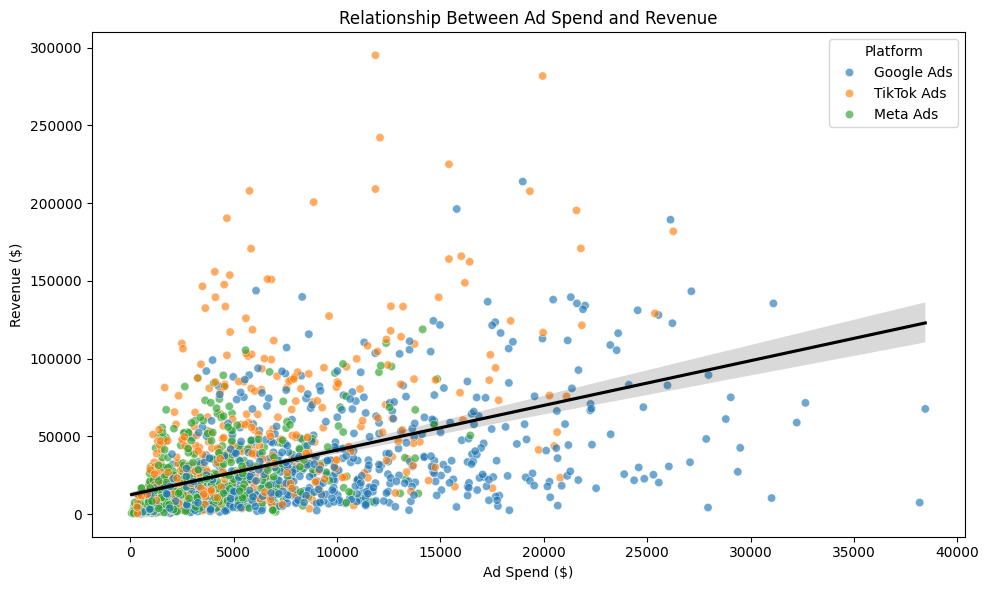

In [19]:
spend_revenue_corr = df["ad_spend"].corr(df["revenue"])

spend_conversions_corr = df["ad_spend"].corr(df["conversions"])

spend_roas_corr = df["ad_spend"].corr(df["ROAS"])

print("Ad spend vs. revenue correlation:", round(spend_revenue_corr, 2))

print("Ad spend vs. conversions correlation:", round(spend_conversions_corr, 2))

print("Ad spend vs. ROAS correlation:", round(spend_roas_corr, 2))

plt.figure(figsize=(10, 6))

sns.scatterplot(

    data=df,

    x="ad_spend",

    y="revenue",

    hue="platform",

    alpha=0.65

)

sns.regplot(

    data=df,

    x="ad_spend",

    y="revenue",

    scatter=False,

    color="black"

)

plt.title("Relationship Between Ad Spend and Revenue")

plt.xlabel("Ad Spend ($)")

plt.ylabel("Revenue ($)")

plt.legend(title="Platform")

plt.tight_layout()

plt.show()

## Key Findings and Recommendations

### Key Findings

- TikTok Ads delivered the strongest overall platform performance, with a ROAS of 7.62 and a CPA of \$21.67.
- Search was the strongest campaign type, producing a ROAS of 5.31 and the lowest campaign-type CPA of \$31.64.
- SaaS generated the highest conversions and revenue among industries and achieved a ROAS of 5.04.
- India was the most efficient country, with the highest ROAS of 5.50 and the lowest CPA of \$30.76.
- The UAE generated the highest total conversions and revenue among countries.
- Ad spend had moderate positive relationships with revenue (0.48) and conversions (0.56), but a weak negative relationship with ROAS (-0.26).

### Recommendations

- Prioritize additional budget for TikTok Ads while continuing to monitor performance as spending increases.
- Emphasize Search campaigns because they produced the strongest campaign-type ROAS and lowest CPA.
- Target SaaS opportunities for strong conversion volume and revenue performance.
- Use India for efficient growth and the UAE for higher conversion and revenue volume.
- Avoid increasing budgets based on volume alone; monitor ROAS and CPA to protect efficiency.